In [2]:
#Environment Setup

import pandas as pd #Used for data handling, cleaning, filtering, and grouping
import numpy as np #Useful for numerical operations and handling missing/infinite values.
import matplotlib.pyplot as plt #Used for plotting graphs / data visualization
from matplotlib.ticker import FuncFormatter #Used for formatting numbers on plot axes

#Used to control number of columns and table width
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

plt.rcParams["figure.figsize"] = (12, 6) #width, height (size) of plots
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False



In [ ]:
df_raw = pd.read_csv("data/symbol_info_3-25.csv") #All data befor cleaning / preprocessing
print("Dataset shape:", df_raw.shape) # the result num rows(companies), num columns (features)
df_raw.head() # Preview the first rows


Dataset shape: (1000, 38)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,fifty_day_average,two_hundred_day_avg,beta,pe_trailing,pe_forward,price_to_sales,price_to_book,total_revenue,net_income,profit_margins,free_cashflow,debt_to_equity,return_on_assets,return_on_equity,revenue_growth,earnings_growth,last_annual_dividend,dividend_yield,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
0,AAPL,Apple Inc.,Technology,Consumer Electronics,3278873821184,3321891913728,218.270004,214.100006,260.100006,164.080002,231.919006,228.354950,1.178,34.591125,26.265944,8.285006,49.182064,395760009216,96150003712,0.24295,93833871360,145.000000,0.22519,1.36520,0.040,0.101,1.00,0.46,0.1571,52181373,2.71,NMS,NMS,United States,0,0,1,2025-03-22 04:50:05
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,2908619014144,2939973795840,391.260010,386.839996,468.350006,376.910004,408.945801,423.364349,0.914,31.553228,26.171238,11.109996,9.610435,261802000384,92749996032,0.35428,51958124544,33.998001,0.14649,0.34291,0.123,0.102,3.32,0.85,0.2482,22370941,2.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:07
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,2892136185856,2838940090368,117.699997,118.529999,153.130005,75.606003,126.937798,127.763115,1.765,40.034012,28.567961,22.162472,36.315952,130497003520,72879996928,0.55848,44169748480,12.946000,0.57417,1.19177,0.779,0.836,0.04,0.03,0.0116,271988186,0.84,NMS,NMS,United States,0,0,1,2025-03-22 04:50:06
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,218.631393,199.768295,1.192,35.481014,31.904066,3.259417,7.268114,637959012352,59248001024,0.09287,44635873280,54.341999,0.07438,0.24290,0.105,0.846,0.00,0.00,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08
4,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,1996906430464,1931518148608,163.990005,162.800003,207.050003,147.220001,182.666000,175.225204,1.025,20.396767,18.302456,5.705153,6.159943,350018011136,100118003712,0.28604,56580751360,8.655000,0.16740,0.32908,0.118,0.309,0.80,0.49,0.0746,29147868,2.01,NMS,NMS,United States,0,0,1,2025-03-22 04:50:09


In [4]:
#Create a summary table to understand the dataset structure before cleaning
summary = pd.DataFrame ({

    # List of all column names in the dataset
    "column": df_raw.columns, 
    #عمود جديد سميته كولوم وخليت بياناته تساوي بيانات اعمدة الجدول الاصلي

    # Data type of each column (e.g., float, int, object)
    "dtype": df_raw.dtypes.astype(str).values,
    #dtypes نوع كل عمود
    #astype(str) بيحولها لنصوص

    #Number of missing values in each column
    "missing_values": df_raw.isna().sum().values,
    #.isna() بتحط ترو ازا في قيمة مفقودة
    #.sum() بتجمع كم ترو

    "missing_pct": (df_raw.isna().mean().values * 100).round(2)
    #.mean() نسبة القيم المفقودة لكل عمود, نسبة الترو
    # 100 بتحول الرقم لنسبة مئوية .round(2) رقمين بعد الفاصلة
}) 
# Display the summary table
summary

,column,dtype,missing_values,missing_pct
0,symbol,str,0,0.0
1,company_name,str,0,0.0
2,sector,str,2,0.2
3,industry,str,2,0.2
4,market_cap,int64,0,0.0
5,enterprise_value,uint64,0,0.0
6,current_price,float64,0,0.0
7,previous_close,float64,0,0.0
8,fifty_two_week_high,float64,0,0.0
9,fifty_two_week_low,float64,0,0.0


In [5]:
df = df_raw.copy() #make a copy from the raw dstaset

df = df[
    (df["is_etf"] == 0) & # Remove ETFs from the analysis
    (df["is_fund"] == 0) & # Remove investment funds from the analysis
    (df["is_actively_trading"] == 1) & 
    #تكون الشركة لسا بتتداول بالسوق
    (df["market_cap"] > 0) & # Remove companies with zero or invalid market cap
    #حجم الشركة في السوق
    (df["total_revenue"] > 0) # Remove companies with zero or invalid revenue
    #ايراد الشركة
].copy()

# Convert financial values from dollars to billions for better visualization
df["market_cap_b"] = df["market_cap"] / 1e9
df["enterprise_value_b"] = df["enterprise_value"] / 1e9
df["revenue_b"] = df["total_revenue"] / 1e9
df["net_income_b"] = df["net_income"] / 1e9
df["free_cashflow_b"] = df["free_cashflow"] / 1e9

# Convert financial ratios from decimals to percentages for readability
df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df["earnings_growth_pct"] = df["earnings_growth"] * 100
df["return_on_assets_pct"] = df["return_on_assets"] * 100
df["return_on_equity_pct"] = df["return_on_equity"] * 100


df["dividend_yield_pct"] = df["dividend_yield"]

df = df.replace([np.inf, -np.inf], np.nan)
print("Cleaned investment universe:", df.shape)
df[["symbol", "company_name", "sector", "market_cap_b", "revenue_b", "profit_margin_pct", "beta"]].head()
  

Cleaned investment universe: (993, 49)


,symbol,company_name,sector,market_cap_b,revenue_b,profit_margin_pct,beta
0,AAPL,Apple Inc.,Technology,3278.873821,395.760009,24.295001,1.178
1,MSFT,Microsoft Corporation,Technology,2908.619014,261.802000,35.428002,0.914
2,NVDA,NVIDIA Corporation,Technology,2892.136186,130.497004,55.848002,1.765
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,2079.374705,637.959012,9.287000,1.192
4,GOOGL,Alphabet Inc.,Communication Services,1996.906430,350.018011,28.604001,1.025


In [6]:
# Helper functions for cleaner charts

# Reusable formatter: show numbers as billions with one decimal.
def billions_formatter(x, pos):
    return f"{x:,.0f}B"

# Reusable formatter: show percentages with no decimal places.
def pct_formatter(x, pos):
    return f"{x:.0f}%"

# Reusable helper to remove unnecessary chart borders.
# This gives a cleaner report-style chart.
def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

# Reusable helper to annotate bars in a horizontal bar chart.
def annotate_hbar(ax, fmt="{:.1f}"):
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width, y, "  " + fmt.format(width), va="center", fontsize=12)

In [ ]:
# Filter dataset to include only assigned sector (Consumer Cyclical)

df_sector = df[df["sector"] == "Consumer Cyclical"].copy()
df_sector.head()

,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,fifty_day_average,two_hundred_day_avg,beta,pe_trailing,pe_forward,price_to_sales,price_to_book,total_revenue,net_income,profit_margins,free_cashflow,debt_to_equity,return_on_assets,return_on_equity,revenue_growth,earnings_growth,last_annual_dividend,dividend_yield,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp,market_cap_b,enterprise_value_b,revenue_b,net_income_b,free_cashflow_b,profit_margin_pct,revenue_growth_pct,earnings_growth_pct,return_on_assets_pct,return_on_equity_pct,dividend_yield_pct
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,218.631393,199.768295,1.192,35.481014,31.904066,3.259417,7.268114,637959012352,59248001024,0.09287,44635873280,54.341999,0.07438,0.24290,0.105,0.846,0.00,0.00,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08,2079.374705,2133.579530,637.959012,59.248001,4.463587e+01,9.287000,10.5,84.600002,7.438000,24.290001,0.00
11,TSLA,"Tesla, Inc.",Consumer Cyclical,Auto Manufacturers,799980716032,777646112768,248.710007,236.259995,488.540009,138.800003,335.324799,284.169495,2.507,121.916672,76.762344,8.188972,10.969918,97690001408,7129999872,0.07259,18446744072882676608,18.489000,0.04186,0.10420,0.021,-0.709,0.00,0.00,0.0000,89178046,0.82,NMS,NMS,United States,0,0,1,2025-03-22 04:50:12,799.980716,777.646113,97.690001,7.130000,1.844674e+10,7.259000,2.1,-70.899999,4.186000,10.420000,0.00
25,HD,"Home Depot, Inc. (The)",Consumer Cyclical,Home Improvement Retail,353158561792,408620662784,351.149994,355.519989,439.369995,323.769989,393.155396,384.259888,1.090,23.535522,22.509615,2.213966,52.410450,159514001408,14805999616,0.09282,11604124672,938.101990,0.15585,3.85372,0.141,0.073,9.20,2.62,0.6036,3401605,3.07,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:22,353.158562,408.620663,159.514001,14.806000,1.160412e+01,9.282000,14.1,7.300000,15.584999,385.372019,2.62
39,MCD,McDonald's Corporation,Consumer Cyclical,Restaurants,219339522048,269094010880,305.440002,307.000000,326.320007,243.529999,298.381012,287.136902,0.706,26.816505,24.222046,8.462173,-57.532494,25920000000,8223000064,0.31725,5127249920,0.000000,0.13307,0.00000,-0.003,0.000,7.08,2.32,0.5953,3299281,3.24,NYQ,NYQ,United States,0,0,1,2025-03-22 04:50:35,219.339522,269.094011,25.920000,8.223000,5.127250e+00,31.725001,-0.3,0.000000,13.307001,0.000000,2.32
50,PDD,PDD Holdings Inc.,Consumer Cyclical,Internet Retail,181818310656,382757339136,126.639999,130.919998,164.690002,88.010002,115.060402,120.224899,0.683,12.452311,8.987934,0.461660,0.561507,393836101632,112434511872,0.28549,101496659968,3.385000,0.15886,0.44924,0.244,0.169,0.00,0.00,0.0000,8988963,2.30,NMS,NMS,Ireland,0,0,1,2025-03-22 05:14:42,181.818311,382.757339,393.836102,112.434512,1.014967e+02,28.549001,24.4,16.900000,15.886000,44.924000,0.00


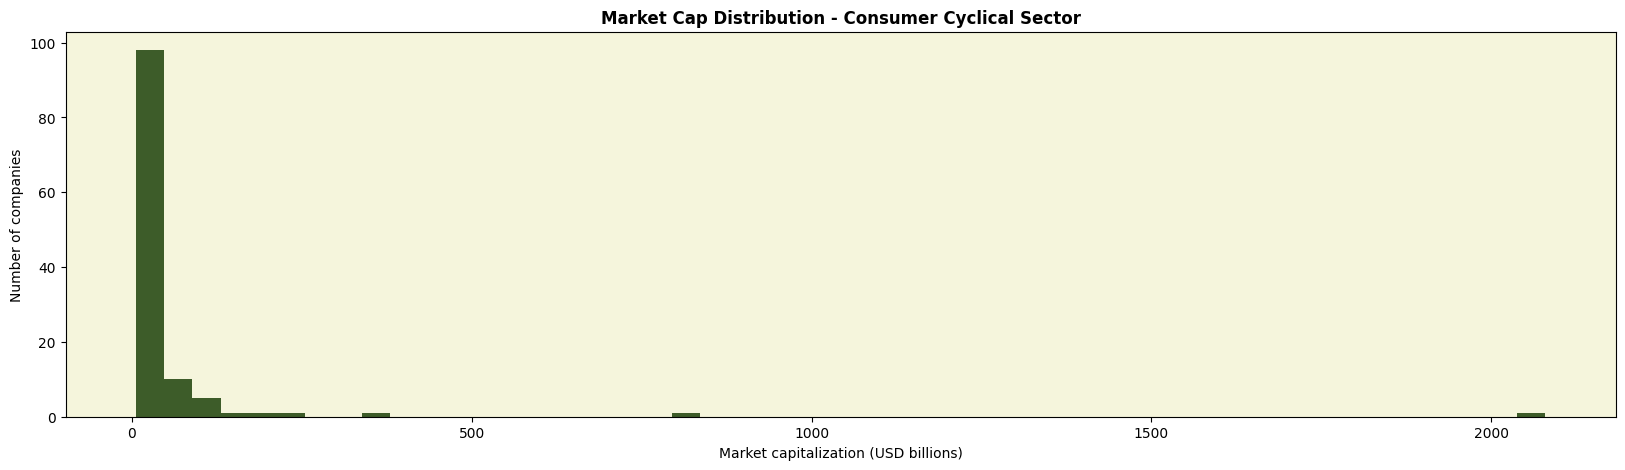

In [15]:
# Histogram of Market Cap for assigned sector (Consumer Cyclical)
#رسم توزيع حجم الشركات

plt.figure(figsize=(20, 5)) #تجهيز ورقة الرسم مع العرض والارتفاع

# Use sector-specific data instead of full dataset
#حددنا القطاع والعمود, ورفعنا القيم الفارغة باستخدام dropna
#bin, تقسيم لقيم market cap , وكل بن بيحتوي ع عدد شركات معين
plt.hist(df_sector["market_cap_b"].dropna(), bins=50, color="#3D5C29")

plt.gca().set_facecolor("#F5F5DC")

# Title clearly indicates the sector
plt.title("Market Cap Distribution - Consumer Cyclical Sector")

plt.xlabel("Market capitalization (USD billions)")
plt.ylabel("Number of companies")

plt.show()

#Most companies are small, and only a few companies have very large market capitalizations

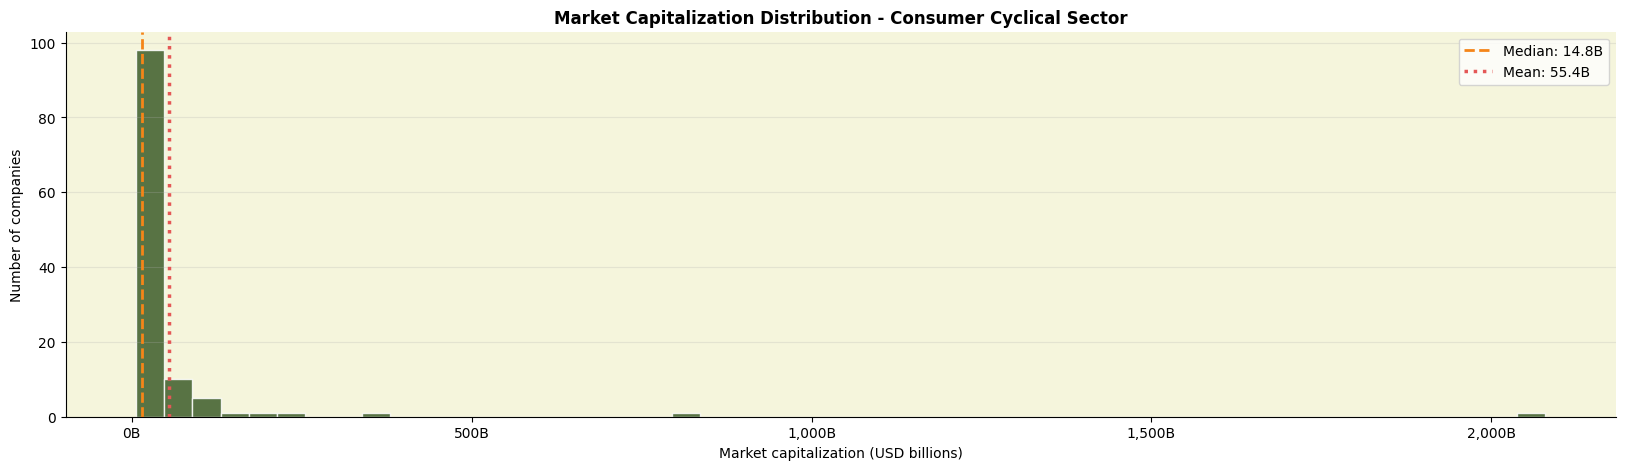

In [18]:
# Store market cap values for the assigned sector
market_cap = df_sector["market_cap_b"].dropna()

# Create figure and axis for the histogram
fig, ax = plt.subplots(figsize=(20, 5))

# Plot histogram of market capitalization
ax.hist(
    market_cap,
    bins=50,
    
    color="#3D5C29",         # Pistachio green color for bars
    
    edgecolor="white",       # White borders separate bars clearly
    
    alpha=0.85               # Slight transparency for softer appearance
)

# Calculate median and mean market capitalization
median_value = market_cap.median()
mean_value = market_cap.mean()

# Add vertical line for median
ax.axvline(
    median_value,
    color="#F58518",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_value:,.1f}B"
)

# Add vertical line for mean
ax.axvline(
    mean_value,
    color="#E45756",
    linestyle=":",
    linewidth=2.5,
    label=f"Mean: {mean_value:,.1f}B"
)
# Beige background color
ax.set_facecolor("#F5F5DC")

# Chart title and axis labels
ax.set_title("Market Capitalization Distribution - Consumer Cyclical Sector")
ax.set_xlabel("Market capitalization (USD billions)")
ax.set_ylabel("Number of companies")

# Format x-axis values as billions
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))

# Add light grid lines on y-axis
ax.grid(axis="y", alpha=0.25)

# Display legend for mean and median lines
ax.legend()

# Remove unnecessary chart borders
clean_spines(ax)

plt.show()

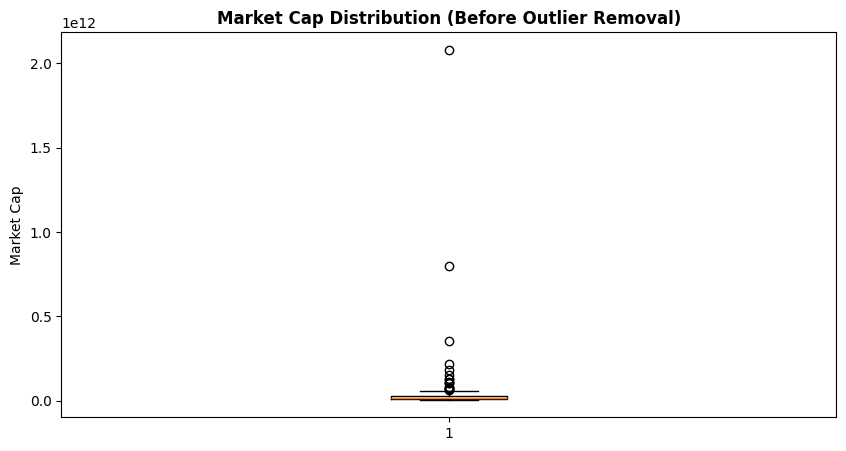

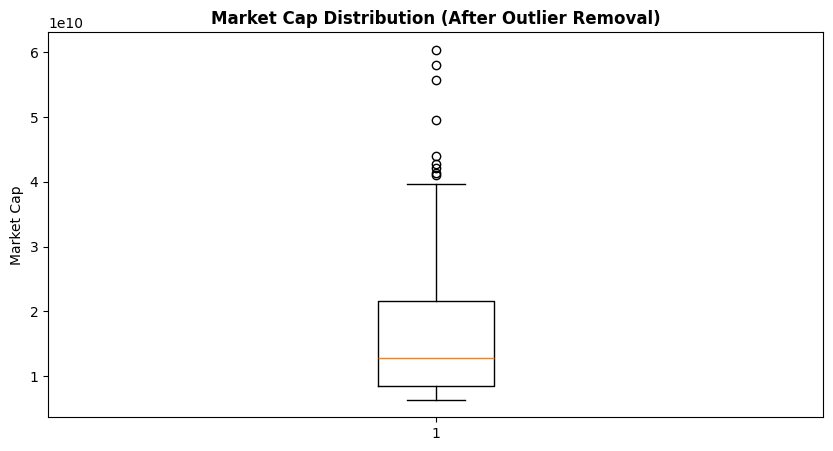

Before cleaning: 119
After cleaning: 102


In [ ]:
# Step 2: Market Cap Outlier Detection (IQR Method)

import matplotlib.pyplot as plt


# 1. Keep only relevant companies (same idea as prof filtering)
# Remove missing values in market_cap
df_step2 = df_sector.dropna(subset=["market_cap"]).copy()

# Optional: remove extremely small companies (like prof revenue filter idea)
# هذا مشابه لفكرة "revenue_b >= 1"
df_step2 = df_step2[df_step2["market_cap"] > 0]

# 2. Boxplot BEFORE cleaning
plt.figure(figsize=(10,5))
plt.boxplot(df_step2["market_cap"])
plt.title("Market Cap Distribution (Before Outlier Removal)")
plt.ylabel("Market Cap")
plt.show()

# 3. IQR OUTLIER DETECTION (proper statistical method)

Q1 = df_step2["market_cap"].quantile(0.25)
Q3 = df_step2["market_cap"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. FILTER DATA (remove outliers)
df_sector_clean = df_step2[
    (df_step2["market_cap"] >= lower_bound) &
    (df_step2["market_cap"] <= upper_bound)
].copy()

# 5. Boxplot AFTER cleaning
plt.figure(figsize=(10,5))
plt.boxplot(df_sector_clean["market_cap"])
plt.title("Market Cap Distribution (After Outlier Removal)")
plt.ylabel("Market Cap")
plt.show()

# 6. Quick comparison (important for explanation later)
print("Before cleaning:", len(df_step2))
print("After cleaning:", len(df_sector_clean))

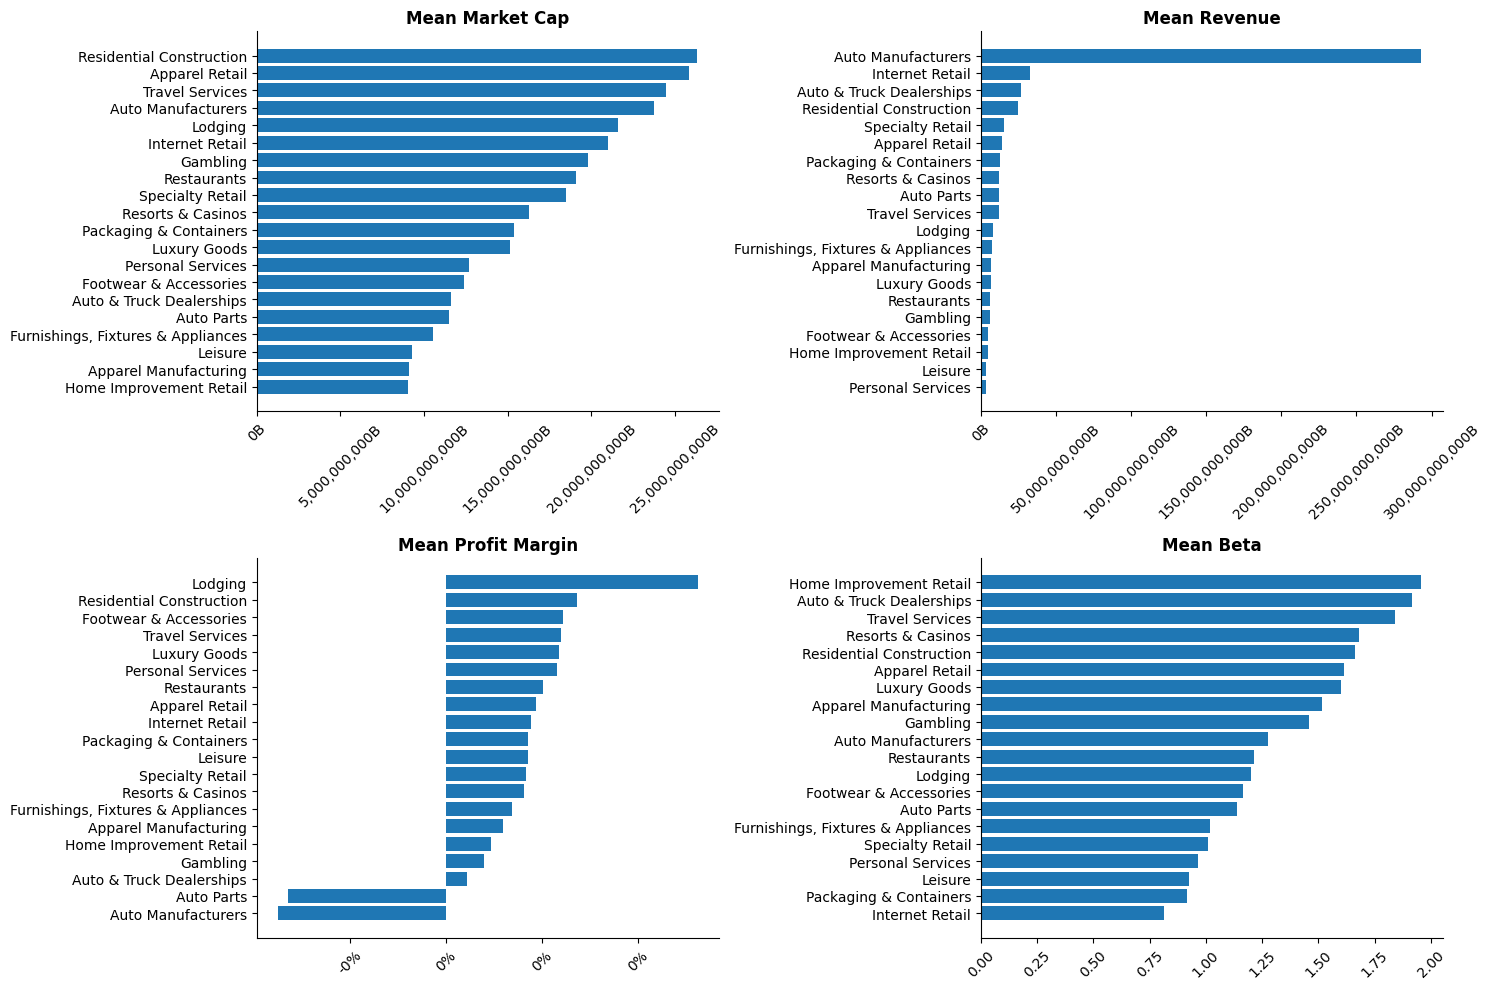

In [30]:
# Step 3: Industry Comparison (Clean Version for Assignment)

import matplotlib.ticker as ticker
metrics = ['market_cap', 'total_revenue', 'profit_margins', 'beta']
titles = ['Mean Market Cap', 'Mean Revenue', 'Mean Profit Margin', 'Mean Beta']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    
    # Group by industry and calculate mean (core requirement)
    data = df_sector_clean.groupby('industry')[metric].mean().sort_values()
    
    # Horizontal bar chart
    axes[i].barh(data.index, data.values)
    axes[i].set_title(titles[i], fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    #axes[i].xaxis.set_major_locator(ticker.MaxNLocator(5))
    #axes[i].tick_params(axis='x', rotation=30)


    # Formatting based on metric type
    
    if 'market_cap' in metric or 'revenue' in metric:
        axes[i].xaxis.set_major_formatter(FuncFormatter(billions_formatter))
    elif 'profit' in metric:
        axes[i].xaxis.set_major_formatter(FuncFormatter(pct_formatter))
    
    clean_spines(axes[i])

plt.tight_layout()
plt.show()

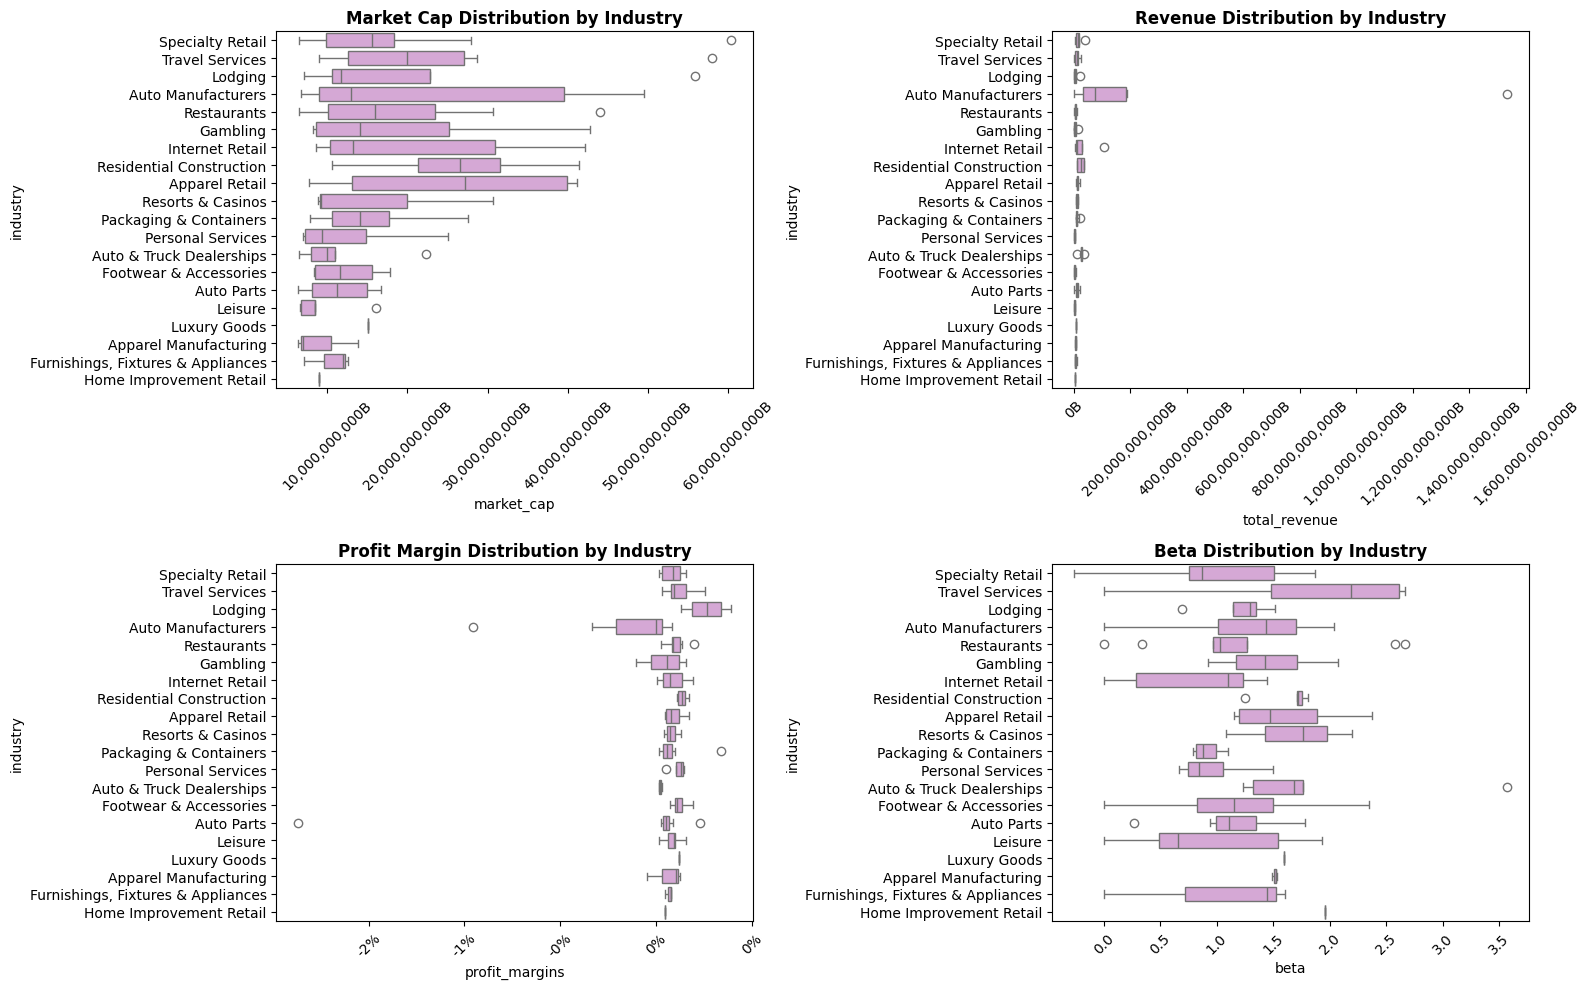

In [40]:
# Step 4: Industry Dispersion (Boxplots)

import seaborn as sns
import matplotlib.pyplot as plt

metrics = [
    "market_cap",
    "total_revenue",
    "profit_margins",
    "beta"
]

titles = [
    "Market Cap Distribution by Industry",
    "Revenue Distribution by Industry",
    "Profit Margin Distribution by Industry",
    "Beta Distribution by Industry"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    
    
    # Boxplot per industry (full distribution, not mean)
    sns.boxplot(
    data=df_sector_clean,
    x=metric,
    y="industry",
    ax=axes[i],
    color="plum"
    )
    
    axes[i].set_title(titles[i], fontweight="bold")
    axes[i].tick_params(axis='x', rotation=45)

    
    # Formatting (optional but clean)
    if metric in ["market_cap", "total_revenue"]:
        axes[i].xaxis.set_major_formatter(FuncFormatter(billions_formatter))
    elif metric == "profit_margins":
        axes[i].xaxis.set_major_formatter(FuncFormatter(pct_formatter))

plt.tight_layout()
plt.show()

In [55]:
# Step 5.
# Keep only the selected industries for deeper analysis

selected_industries = [
    "Lodging",
    "Auto Manufacturers",
    "Residential Construction",
    "Travel Services"
]

df_focus = df_sector[
    df_sector["industry"].isin(selected_industries)
].copy()

# Preview filtered dataset
print(df_focus.shape)
df_focus.head()


(28, 49)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,fifty_day_average,two_hundred_day_avg,beta,pe_trailing,pe_forward,price_to_sales,price_to_book,total_revenue,net_income,profit_margins,free_cashflow,debt_to_equity,return_on_assets,return_on_equity,revenue_growth,earnings_growth,last_annual_dividend,dividend_yield,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp,market_cap_b,enterprise_value_b,revenue_b,net_income_b,free_cashflow_b,profit_margin_pct,revenue_growth_pct,earnings_growth_pct,return_on_assets_pct,return_on_equity_pct,dividend_yield_pct
11,TSLA,"Tesla, Inc.",Consumer Cyclical,Auto Manufacturers,799980716032,777646112768,248.710007,236.259995,488.540009,138.800003,335.324799,284.169495,2.507,121.916672,76.762344,8.188972,10.969918,97690001408,7129999872,0.07259,18446744072882676608,18.489000,0.04186,0.10420,0.021,-0.709,0.000000,0.00,0.0000,89178046,0.82,NMS,NMS,United States,0,0,1,2025-03-22 04:50:12,799.980716,777.646113,97.690001,7.130000,1.844674e+10,7.259000,2.100000,-70.899999,4.186000,10.420000,0.00
68,BKNG,Booking Holdings Inc. Common St,Consumer Cyclical,Travel Services,151516299264,152588320768,4617.259766,4589.029785,5337.240234,3180.000000,4782.444336,4409.454102,1.404,26.737272,22.002666,6.382589,-37.841740,23739000832,5881999872,0.24778,7449750016,0.000000,0.18225,0.00000,0.144,4.091,38.400002,0.83,0.2027,271455,2.33,NMS,NMS,United States,0,0,1,2025-03-22 04:50:47,151.516299,152.588321,23.739001,5.882000,7.449750e+00,24.778000,14.399999,409.100008,18.225001,0.000000,0.83
141,RACE,Ferrari N.V.,Consumer Cyclical,Auto Manufacturers,81097924608,79728386048,436.320007,444.029999,509.130005,399.269989,454.459015,447.355042,0.584,47.169731,45.783844,12.146467,22.105583,6676667904,1521876992,0.22794,466514112,94.599998,0.13420,0.46143,0.139,0.324,3.110000,0.71,0.2888,368636,3.32,NYQ,NYQ,Italy,0,0,1,2025-03-22 04:52:18,81.097925,79.728386,6.676668,1.521877,4.665141e-01,22.794001,13.900000,32.400000,13.420001,46.143001,0.71
149,ABNB,"Airbnb, Inc.",Consumer Cyclical,Travel Services,78382022656,71711539200,128.800003,126.150002,170.000000,110.379997,135.003799,134.368820,1.108,30.666668,28.622223,7.060171,9.539328,11102000128,2648000000,0.23852,3145625088,27.271000,0.07671,0.31948,0.118,0.000,0.000000,0.00,0.0000,5042038,2.46,NMS,NMS,United States,0,0,1,2025-03-22 04:52:07,78.382023,71.711539,11.102000,2.648000,3.145625e+00,23.852000,11.800000,0.000000,7.671000,31.948000,0.00
179,MAR,Marriott International,Consumer Cyclical,Lodging,67501309952,80423878656,237.490005,244.839996,307.519989,204.550003,275.201813,258.143555,1.586,29.428751,22.404716,10.199655,-21.961348,6617999872,2375000064,0.35887,1950499968,0.000000,0.09341,0.00000,0.029,-0.433,2.520000,1.03,0.2893,1626448,2.93,NMS,NMS,United States,0,0,1,2025-03-22 04:51:55,67.501310,80.423879,6.618000,2.375000,1.950500e+00,35.887000,2.900000,-43.300000,9.340999,0.000000,1.03


Industry Selection Justification

1. Lodging
This industry was selected because it has the highest average profit margins in the sector. The boxplots also showed relatively stable and consistent profitability, making it a strong and profitable industry for further analysis.
2. Auto Manufacturers
This industry was selected because it has the highest average revenue by a large margin compared to other industries. Even though its profit margins are negative, its very large economic size makes it interesting to analyze in the Bubble Chart.
3. Residential Construction
This industry was selected because it has the highest average market capitalization in the sector. It also showed strong profit margins and a relatively stable distribution in the boxplots, representing one of the strongest industries in terms of company size and profitability.
4. Travel Services
This industry was selected to include a higher-risk industry in the analysis. It showed one of the highest beta values, meaning it is more sensitive to market changes. At the same time, it maintained good market capitalization and profitability levels.
____________________________________

Why Other Industries Were Excluded
Industries such as Internet Retail and Packaging & Containers were excluded because their performance was relatively average across the four metrics compared to the selected industries. As a result, they were less likely to provide strong analytical insights in the Bubble Chart analysis.

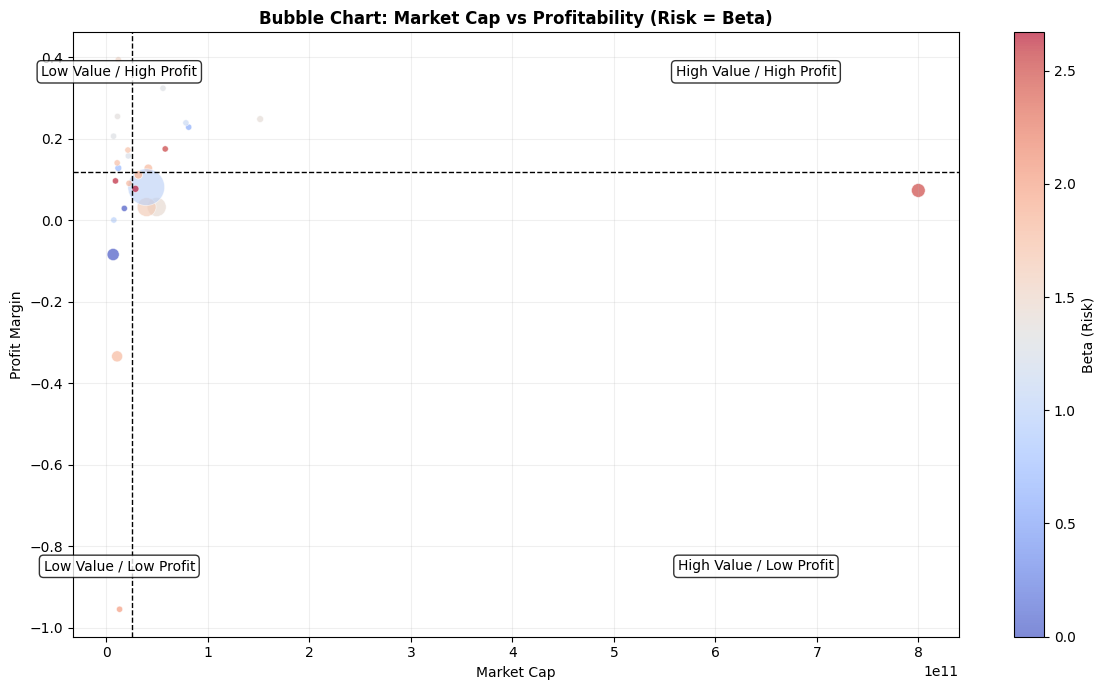

In [57]:
# Step 6 visualizes relationship between valuation (market cap),
# profitability, scale (revenue), and risk (beta).
# Quadrants are based on median splits to ensure balanced grouping.


# Bubble Chart with Quadrants (Clean Version)

import matplotlib.pyplot as plt

# ============================================================
# Step 6: Bubble Chart (Market Cap vs Profitability vs Risk)
# ============================================================

# Clean the dataset to ensure all required variables exist for visualization
df_step6 = df_focus.dropna(subset=[
    "market_cap",
    "profit_margins",
    "total_revenue",
    "beta"
]).copy()

fig, ax = plt.subplots(figsize=(12, 7))

# ------------------------------------------------------------
# Bubble size represents company scale (total revenue)
# Values are scaled to make visualization readable
# ------------------------------------------------------------
sizes = (df_step6["total_revenue"] / 1e9).clip(lower=20, upper=700)

# ------------------------------------------------------------
# Scatter plot:
# X-axis → Market Capitalization (company valuation)
# Y-axis → Profit Margin (profitability)
# Color → Beta (risk level)
# ------------------------------------------------------------
points = ax.scatter(
    df_step6["market_cap"],
    df_step6["profit_margins"],
    s=sizes,
    c=df_step6["beta"],
    cmap="coolwarm",
    alpha=0.65,
    edgecolors="white",
    linewidth=0.5
)

# ------------------------------------------------------------
# Median lines used to split the data into four quadrants
# ------------------------------------------------------------
x_median = df_step6["market_cap"].median()
y_median = df_step6["profit_margins"].median()

ax.axvline(x_median, color="black", linewidth=1, linestyle='--')
ax.axhline(y_median, color="black", linewidth=1, linestyle='--')

# ------------------------------------------------------------
# Define plot boundaries for positioning quadrant labels
# ------------------------------------------------------------
x_max = df_step6["market_cap"].max()
y_min = df_step6["profit_margins"].min()
y_max = df_step6["profit_margins"].max()

# Styling for quadrant labels
bbox_props = dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  alpha=0.8,
                  edgecolor="black")

# ------------------------------------------------------------
# Quadrant labels interpretation
# ------------------------------------------------------------
ax.text(x_max * 0.8, y_max * 0.9,
        "High Value / High Profit",
        ha="center", bbox=bbox_props)

ax.text(x_median * 0.5, y_max * 0.9,
        "Low Value / High Profit",
        ha="center", bbox=bbox_props)

ax.text(x_max * 0.8, y_min * 0.9,
        "High Value / Low Profit",
        ha="center", bbox=bbox_props)

ax.text(x_median * 0.5, y_min * 0.9,
        "Low Value / Low Profit",
        ha="center", bbox=bbox_props)

# ------------------------------------------------------------
# Axis labels and title
# ------------------------------------------------------------
ax.set_xlabel("Market Cap")
ax.set_ylabel("Profit Margin")
ax.set_title("Bubble Chart: Market Cap vs Profitability (Risk = Beta)")

# ------------------------------------------------------------
# Colorbar represents risk (Beta)
# ------------------------------------------------------------
cbar = plt.colorbar(points)
cbar.set_label("Beta (Risk)")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

I selected The "Low Value / High Profit" quadrant because it represents companies that generate strong profitability despite having relatively lower market valuations. This combination makes the quadrant interesting for further analysis, as it may contain potentially undervalued but financially efficient companies. In addition, these companies may react differently to market uncertainty and geopolitical events compared to larger high-valuation firms.

,symbol,company_name,market_cap,profit_margins,beta
690,H,Hyatt Hotels Corporation,11782204416,0.39320,1.516
723,MMYT,MakeMyTrip Limited,10966121472,0.25425,1.363
941,WH,"Wyndham Hotels & Resorts, Inc.",7085763584,0.20584,1.296
473,PHM,"PulteGroup, Inc.",21234999296,0.17180,1.725
463,NVR,"NVR, Inc.",21637857280,0.15737,1.254
739,TOL,"Toll Brothers, Inc.",10656611328,0.14030,1.763
691,HTHT,H World Group Limited,11781358592,0.12758,0.690


[*********************100%***********************]  7 of 7 completed


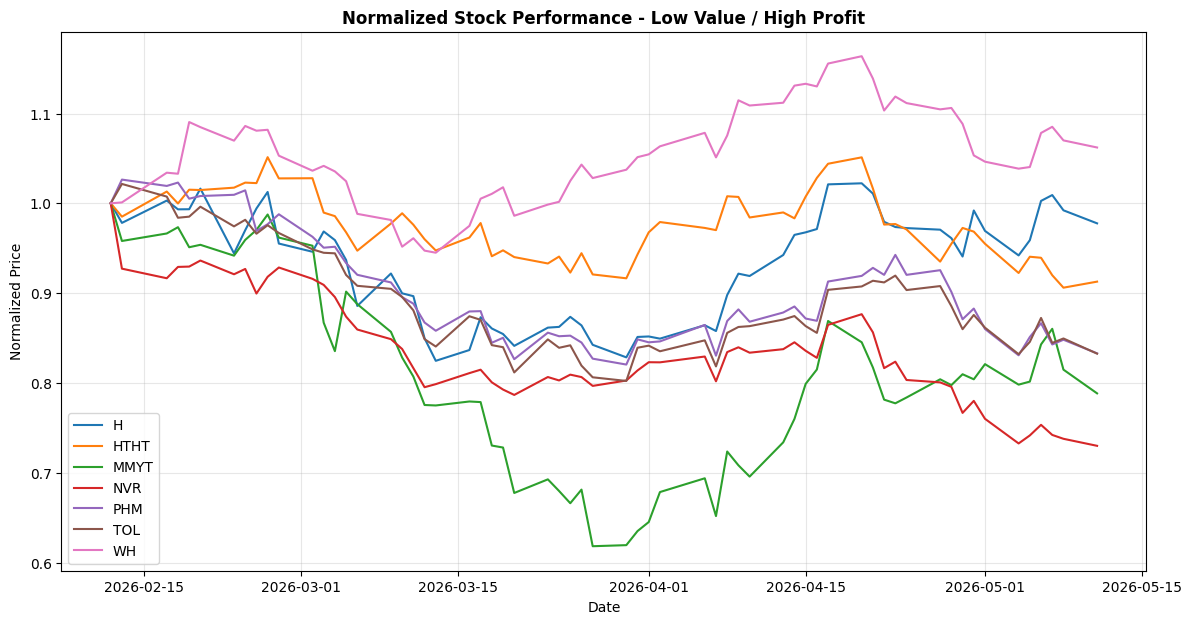

In [63]:
# ============================================================
# Step 7: Select companies from the chosen quadrant
# Low Value / High Profit
# ============================================================
import yfinance as yf

# Filter companies inside the selected quadrant
quadrant_1 = df_step6[
    (df_step6["market_cap"] < x_median) &
    (df_step6["profit_margins"] > y_median)
].copy()

# Keep top 10 companies by profit margin
quadrant_1 = quadrant_1.nlargest(10, "profit_margins")

# Preview selected companies
display(
    quadrant_1[["symbol", "company_name", "market_cap", "profit_margins", "beta"]]
)
# Extract ticker symbols from selected quadrant
tickers = quadrant_1["symbol"].tolist()

# Download last 3 months of daily closing prices
prices = yf.download(
    tickers,
    period="3mo",
    interval="1d"
)["Close"]

# Normalize all series to 1 on the first trading day
normalized_prices = prices / prices.iloc[0]

# ------------------------------------------------------------
# Plot normalized stock performance
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

for column in normalized_prices.columns:
    plt.plot(
        normalized_prices.index,
        normalized_prices[column],
        label=column
    )

plt.title("Normalized Stock Performance - Low Value / High Profit")
plt.xlabel("Date")
plt.ylabel("Normalized Price")

plt.legend()
plt.grid(alpha=0.3)

plt.show()




- Price Performance Observations:

* Normalization & Divergence: All series were normalized to 1 on the first trading day to ensure a fair comparison. Over the three-month period, a significant divergence in performance is observed. While companies started at the same point, their trajectories varied greatly by May.

* Top Performer: WH (Wyndham Hotels) stands out as the most resilient stock, being the only one to consistently trade above its starting value, peaking near 1.15 despite the broader market volatility.

* Underperformers: MMYT (MakeMyTrip) and NVR experienced the most significant declines. Specifically, MMYT dropped to a level of 0.6 in March, representing a 40% loss in value during the peak of market uncertainty.


- Geopolitical Reflection (Strait of Hormuz Tensions):

* The Sharp Drop: A visible sharp drop occurred across almost all tickers between mid-February and late March. This period aligns with heightened geopolitical tensions in the Strait of Hormuz, which directly impacts global energy prices and shipping routes. 

* Sector Sensitivity: Given that this quadrant includes several companies from the Lodging and Travel Services industries (such as H, HTHT, and MMYT), the sensitivity to these tensions was high. Rising fuel costs and regional instability typically lead to reduced global travel demand and increased operational expenses for these firms.


- Recovery Signs:

* Partial Recovery: A noticeable recovery wave began in April for the majority of the stocks in this quadrant.  

* Ongoing Instability: Despite the April rebound, most stocks failed to return to their initial baseline (1.0). The recent downward trend in early May suggests that a full recovery is still hindered by persistent regional instability and market anxiety.

,symbol,company_name,market_cap,profit_margins,beta
11,TSLA,"Tesla, Inc.",799980716032,0.07259,2.507
241,GM,General Motors Company,49551097856,0.03205,1.434
293,F,Ford Motor Company,39674097664,0.03178,1.607
298,MAHMF,Mahindra & Mahindra Ltd.,39283859456,0.08071,1.052
354,LEN,Lennar Corporation,31519354880,0.11096,1.710
355,LEN-B,Lennar Corporation,31519301632,0.11096,1.710
377,CCL,Carnival Corporation,28660158464,0.07658,2.669


[*********************100%***********************]  7 of 7 completed


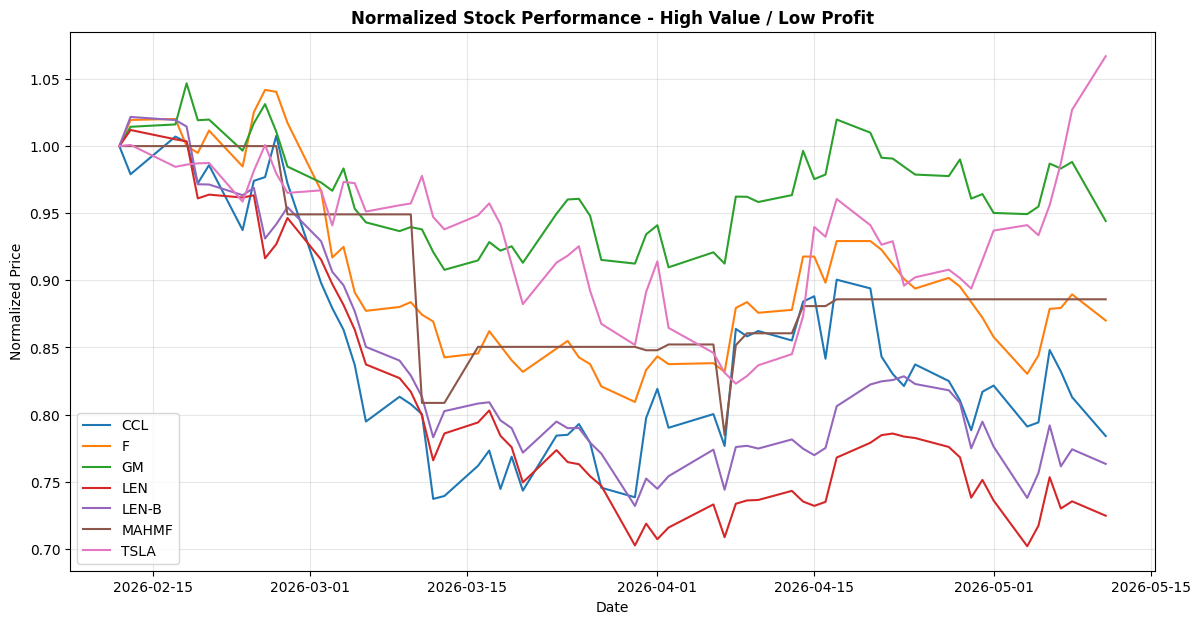

In [64]:
# ============================================================
# Step 8: Compare with a different quadrant
# High Value / Low Profit
# ============================================================

import yfinance as yf
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Select companies in opposite quadrant
# ------------------------------------------------------------
quadrant_2 = df_step6[
    (df_step6["market_cap"] > x_median) &
    (df_step6["profit_margins"] < y_median)
].copy()

# Keep top 10 companies (based on market cap for stability)
quadrant_2 = quadrant_2.nlargest(10, "market_cap")

# Show selected companies
display(
    quadrant_2[["symbol", "company_name", "market_cap", "profit_margins", "beta"]]
)

# Extract tickers
tickers_2 = quadrant_2["symbol"].tolist()

# ------------------------------------------------------------
# Download last 3 months of stock prices
# ------------------------------------------------------------
prices_2 = yf.download(
    tickers_2,
    period="3mo",
    interval="1d"
)["Close"]

# Normalize to 1
normalized_prices_2 = prices_2 / prices_2.iloc[0]

# ------------------------------------------------------------
# Plot performance
# ------------------------------------------------------------
plt.figure(figsize=(14, 7))

for col in normalized_prices_2.columns:
    plt.plot(
        normalized_prices_2.index,
        normalized_prices_2[col],
        label=col
    )

plt.title("Normalized Stock Performance - High Value / Low Profit")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Comparison between quadrants

The companies in Step 7 (Low Value / High Profit) generally showed better growth potential. Some of them were quite volatile, but overall they had more upside compared to expectations.

On the other hand, the companies in Step 8 (High Value / Low Profit) were more stable, but their performance was weaker. In some cases, they stayed flat or even slightly declined because their profitability was not strong enough to support their high market value.

Overall, splitting companies into quadrants helped make more sense of how financial data connects to real stock performance. It also made it easier to see how different types of companies react differently, especially when there are geopolitical tensions like those in the Strait of Hormuz.

Final Summary

In this analysis, I studied a specific sector by filtering companies and focusing only on active firms, while removing ETFs and missing or irrelevant data. The goal was to understand how companies behave financially inside the same sector and how different industries compare with each other.

First, I looked at the market capitalization distribution. This helped me see that the sector is not balanced: a small number of companies are very large, while most companies are much smaller. The mean and median were different, which shows that the data is skewed by a few big firms.

After that, I removed outliers using the IQR method. This step was important because extreme values can distort the analysis, especially when comparing industries. After cleaning the data, I worked with a more realistic dataset that better represents normal market behavior.

In Step 3, I compared industries using four main metrics: market cap, total revenue, profit margins, and beta. This gave a clear picture of which industries are large, which are profitable, and which are more risky. Some industries were strong in size but weaker in profitability, while others showed the opposite pattern.

In Step 4, I used boxplots to look at the full distribution of each metric by industry. This was important because averages alone can hide variation. Some industries had very stable values, while others had a wide spread, showing higher uncertainty and risk.

Based on these results, I selected a few industries that showed meaningful differences and enough variation for deeper analysis. Industries that were too small or too inconsistent were excluded because they did not add much value to the comparison.

In Step 6, I created a bubble chart to combine market cap, profitability, revenue, and risk (beta) in one visualization. This helped me see the structure of the sector more clearly. I also divided the chart into four quadrants, which helped group companies based on value and profitability.

In Steps 7 and 8, I selected two different quadrants and analyzed their stock performance over the last three months. I normalized the prices to compare them fairly. The results showed clear differences: companies with lower value but higher profitability had more growth potential, while high-value but low-profit companies were more stable but weaker in performance.

Finally, when relating this to geopolitical uncertainty, especially tensions in the Strait of Hormuz, some volatility was visible in both groups. However, stronger and more efficient companies recovered faster, while weaker ones showed slower or flat performance.

Overall, the quadrant approach helped connect financial fundamentals with real market behavior in a simple and useful way.

In [61]:
import sys
!{sys.executable} -m pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 16.3 MB/s  0:00:00

   ----------------------------------------  0/21 [pytz]
   ----------------------------------------  0/21 [pytz]
   ----------------------------------------  0/21 [pytz]
   ----------------------------------------  0/21 [pytz]
   ----------------------------------------  0/21 [pytz]
   ----------------------------------------  0/21 [pytz]
   ----------------------------------------  0/21 [pytz]
   - --------------------------------------  1/21 [peewee]
   - --------------------------------------  1/21 [peewee]
   - --------------------------------------  1/21 [peewee]
   - --------------------------------------  1/21 [peewee]
   - --------------------------------------  1/21 [peewee]
   - --------------------------------------  1/21 [peewee]
   - --------------------------------------  1/21 [peewee]
   - -------------------------------------- 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
